In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('Metrics Score 2018-2025.csv')
df

,File Name,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number Of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Class,Semester,Year
0,/Users/summer-2024/Desktop/code metrics 25/All...,403,7.196,18.114144,14.888337,28,187,14.392857,-1,4,1.242,6,CS5,s2018,2018
1,/Users/summer-2024/Desktop/code metrics 25/All...,546,8.974,15.567766,16.849817,29,206,18.827586,41,3,1.297,6,CS5,s2018,2018
2,/Users/summer-2024/Desktop/code metrics 25/All...,464,53.448,11.637931,16.379310,11,69,42.181818,10,2,1.284,6,CS5,s2018,2018
3,/Users/summer-2024/Desktop/code metrics 25/All...,496,16.331,9.274194,17.540323,14,124,35.428571,1,2,1.310,4,CS5,s2018,2018
4,/Users/summer-2024/Desktop/code metrics 25/All...,315,34.286,13.650794,20.952381,9,57,35.000000,2,2,1.303,5,CS5,s2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,/Users/summer-2024/Desktop/code metrics 25/All...,759,44.796,6.982872,26.482213,7,48,108.428571,-1,2,1.283,5,CS35,sp2025,2025
1576,/Users/summer-2024/Desktop/code metrics 25/All...,1128,28.635,9.840426,29.787234,25,91,45.120000,-1,3,NaN,6,IST341,sp2025,2025
1577,/Users/summer-2024/Desktop/code metrics 25/All...,551,45.554,8.529946,25.589837,4,26,137.750000,-1,1,1.267,5,IST341,sp2025,2025
1578,/Users/summer-2024/Desktop/code metrics 25/All...,188,30.851,0.000000,22.872340,0,16,0.000000,5,0,1.269,5,CS35,sp2025,2025


In [3]:
df_tidy = df.dropna()  # NaN values are execution times that timed out by 10 sec
df_tidy = df_tidy.drop('File Name', axis=1)
df_tidy = df_tidy.rename(columns={'Number Of Functions': 'Number of Functions'})
df_tidy

,LOC,Comment Percentage,Docstring Percentage,Empty Percentage,Number of Functions,Number of Loops,CycloComplexity,Average Function Length,Max Depth,Execution Time,Weeks Covered,Class,Semester,Year
0,403,7.196,18.114144,14.888337,28,187,14.392857,-1,4,1.242,6,CS5,s2018,2018
1,546,8.974,15.567766,16.849817,29,206,18.827586,41,3,1.297,6,CS5,s2018,2018
2,464,53.448,11.637931,16.379310,11,69,42.181818,10,2,1.284,6,CS5,s2018,2018
3,496,16.331,9.274194,17.540323,14,124,35.428571,1,2,1.310,4,CS5,s2018,2018
4,315,34.286,13.650794,20.952381,9,57,35.000000,2,2,1.303,5,CS5,s2018,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,800,24.750,4.125000,37.250000,7,11,114.285714,3,1,1.288,7,CS35,sp2025,2025
1575,759,44.796,6.982872,26.482213,7,48,108.428571,-1,2,1.283,5,CS35,sp2025,2025
1577,551,45.554,8.529946,25.589837,4,26,137.750000,-1,1,1.267,5,IST341,sp2025,2025
1578,188,30.851,0.000000,22.872340,0,16,0.000000,5,0,1.269,5,CS35,sp2025,2025


In [4]:
all_metrics = [
    'LOC', 
    'Comment Percentage', 
    'Docstring Percentage', 
    'Empty Percentage', 
    'Number of Functions', 
    'Number of Loops', 
    'CycloComplexity', 
    'Average Function Length', 
    'Max Depth', 
    'Execution Time', 
    'Weeks Covered'
]

#### Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

In [6]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print(y_train_over.value_counts())

Year
2022    335
2024    335
2018    335
2025    335
2019    335
2023    335
2021    335
2020    335
Name: count, dtype: int64


In [8]:
param_grid = {
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 4],
    'min_samples_split': [2, 4],
    'n_estimators': [175, 200, 225]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_over, y_train_over)

best_rf = grid_search.best_estimator_
print(f'Best hyperparameters: {grid_search.best_params_}')
# Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 225}

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 225}


In [9]:
y_pred = best_rf.predict(X_test)

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        2018       0.34      0.36      0.35        36
        2019       0.50      0.43      0.46        58
        2020       0.14      0.14      0.14         7
        2021       0.20      0.08      0.12        24
        2022       0.65      0.77      0.70        90
        2023       0.36      0.26      0.30        31
        2024       0.42      0.50      0.46        34
        2025       0.77      0.96      0.86        28

    accuracy                           0.53       308
   macro avg       0.42      0.44      0.42       308
weighted avg       0.50      0.53      0.51       308



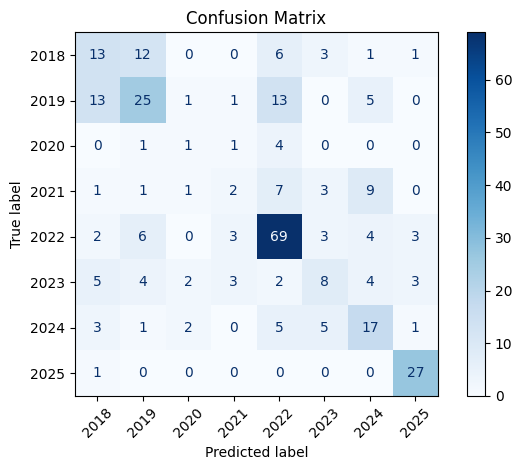

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=sorted(df['Year'].unique()),
    cmap='Blues',
    xticks_rotation=45
)

plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

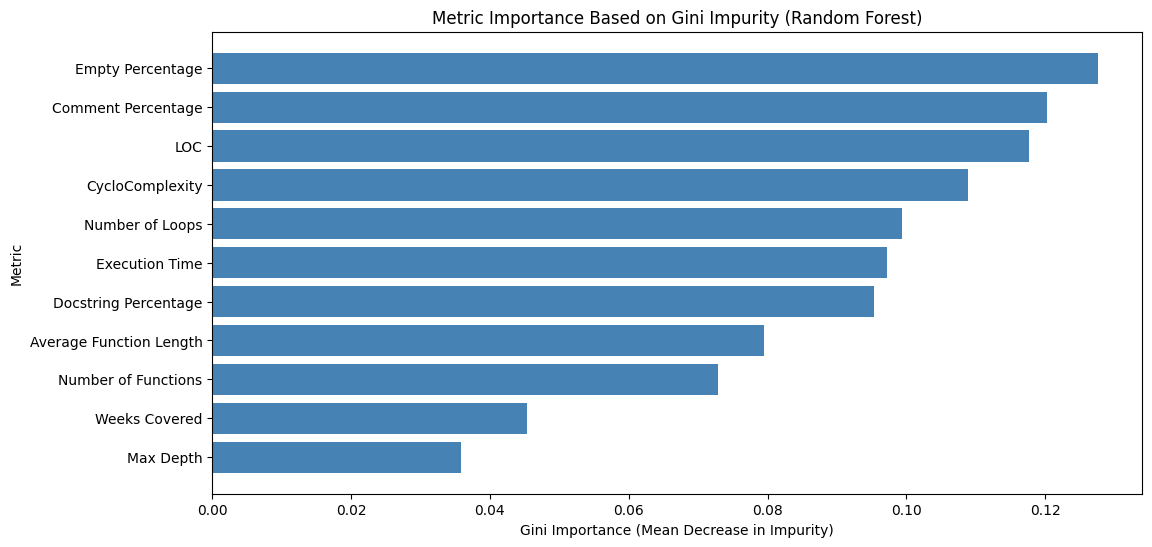

In [12]:
gini_importance = best_rf.feature_importances_

sorted_index = np.argsort(gini_importance)

plt.figure(figsize=(12, 6))
plt.barh(np.array(all_metrics)[sorted_index], np.array(gini_importance)[sorted_index], color='steelblue')
plt.xlabel('Gini Importance (Mean Decrease in Impurity)')
plt.ylabel('Metric')
plt.title('Metric Importance Based on Gini Impurity (Random Forest)')
plt.show()

#### Neural Network

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

In [14]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print(y_train_over.value_counts())

scaler = StandardScaler()
X_train_over_scaled = scaler.fit_transform(X_train_over)
X_test_scaled = scaler.transform(X_test)

Year
2022    335
2024    335
2018    335
2025    335
2019    335
2023    335
2021    335
2020    335
Name: count, dtype: int64


In [ ]:
mlp = MLPClassifier(max_iter=200, random_state=42)

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring='accuracy', verbose=2)
grid_search.fit(X_train_over_scaled, y_train_over)

print(f'Best hyperparameters: {grid_search.best_params_}')
# Best hyperparameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}

In [20]:
best_mlp = grid_search.best_estimator_
y_pred = best_mlp.predict(X_test_scaled)

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        2018       0.34      0.56      0.43        36
        2019       0.57      0.45      0.50        58
        2020       0.17      0.14      0.15         7
        2021       0.23      0.12      0.16        24
        2022       0.62      0.57      0.59        90
        2023       0.40      0.39      0.39        31
        2024       0.40      0.41      0.41        34
        2025       0.74      1.00      0.85        28

    accuracy                           0.50       308
   macro avg       0.43      0.45      0.44       308
weighted avg       0.50      0.50      0.49       308



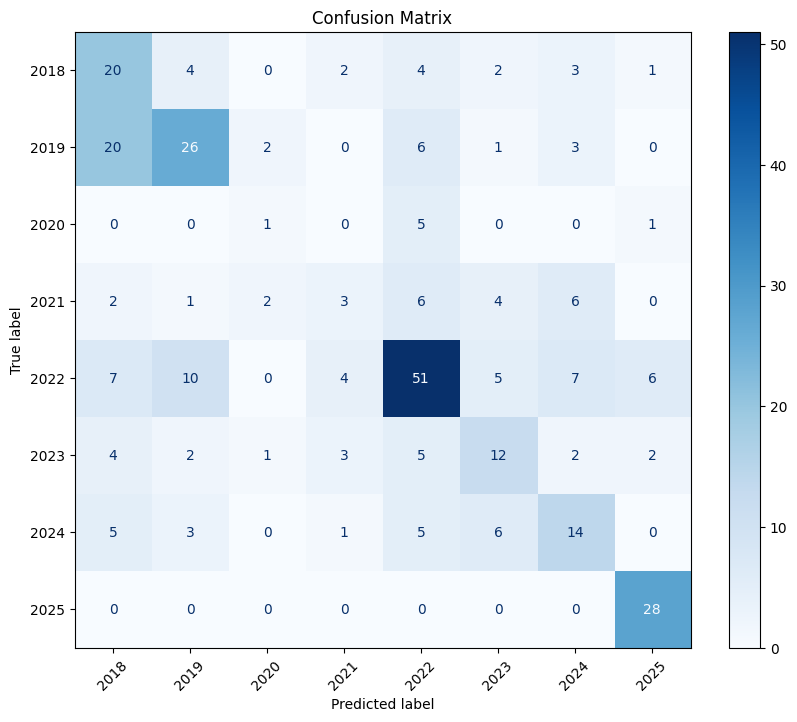

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

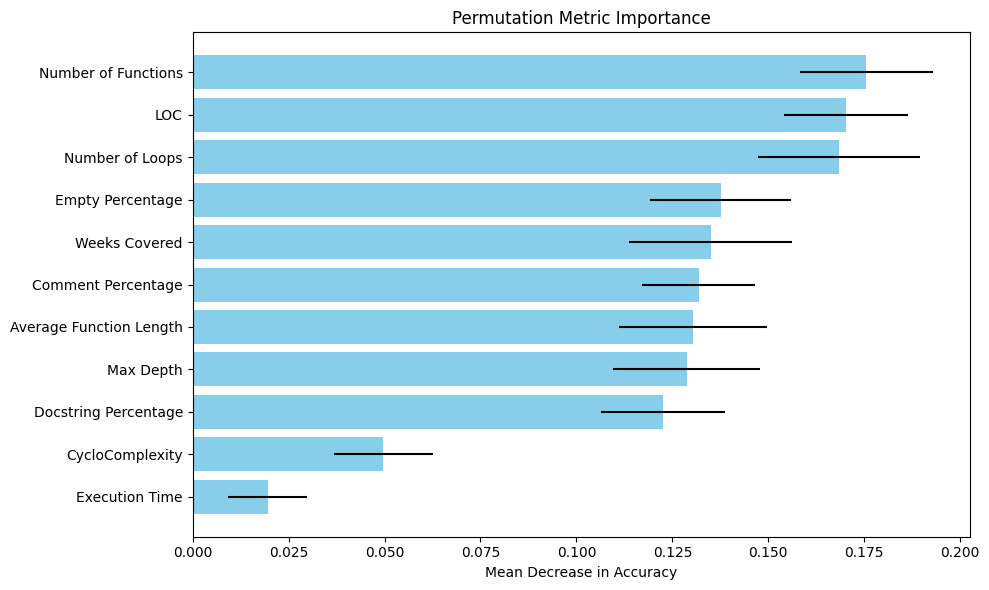

In [25]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_mlp, X_test_scaled, y_test, 
    n_repeats=30, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance_mean'], 
         xerr=importance_df['importance_std'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Permutation Metric Importance')
plt.xlabel('Mean Decrease in Accuracy')
plt.tight_layout()
plt.show()


#### K Nearest Neighbors

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
X = df_tidy[all_metrics]
y = df_tidy['Year']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print(y_train_over.value_counts())

scaler = StandardScaler()
X_train_over_scaled = scaler.fit_transform(X_train_over)
X_test_scaled = scaler.transform(X_test)

Year
2022    335
2024    335
2018    335
2025    335
2019    335
2023    335
2021    335
2020    335
Name: count, dtype: int64


In [ ]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [2, 3, 4, 5, 6],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=2)
grid_search.fit(X_train_over_scaled, y_train_over)

best_knn = grid_search.best_estimator_
print(f'Best hyperparameters: {grid_search.best_params_}')
# Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'distance'}

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=2, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, we

In [36]:
y_pred = best_knn.predict(X_test_scaled)

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        2018       0.38      0.47      0.42        36
        2019       0.52      0.55      0.54        58
        2020       0.33      0.43      0.38         7
        2021       0.25      0.17      0.20        24
        2022       0.67      0.60      0.63        90
        2023       0.33      0.29      0.31        31
        2024       0.42      0.44      0.43        34
        2025       0.79      0.93      0.85        28

    accuracy                           0.52       308
   macro avg       0.46      0.48      0.47       308
weighted avg       0.52      0.52      0.52       308



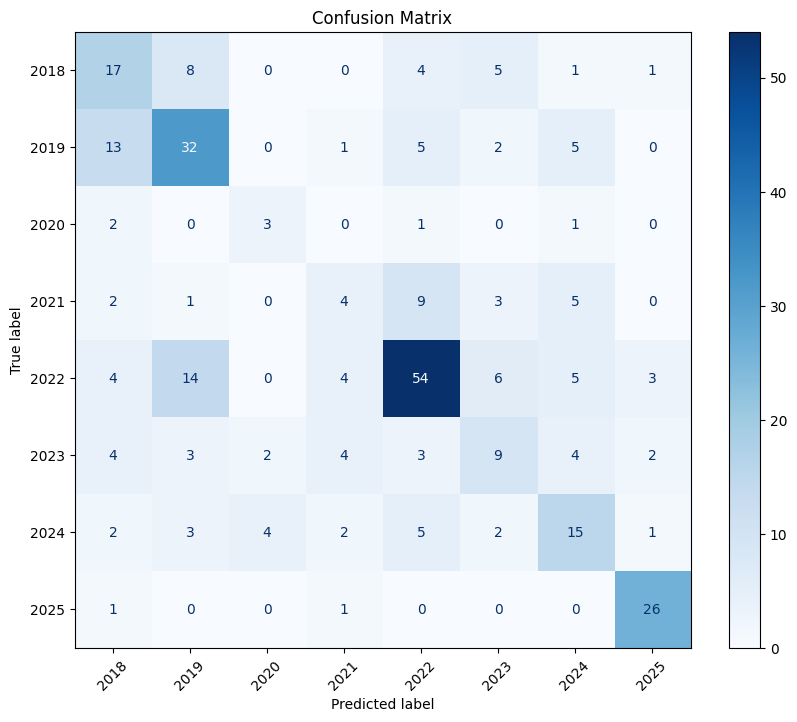

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=best_knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

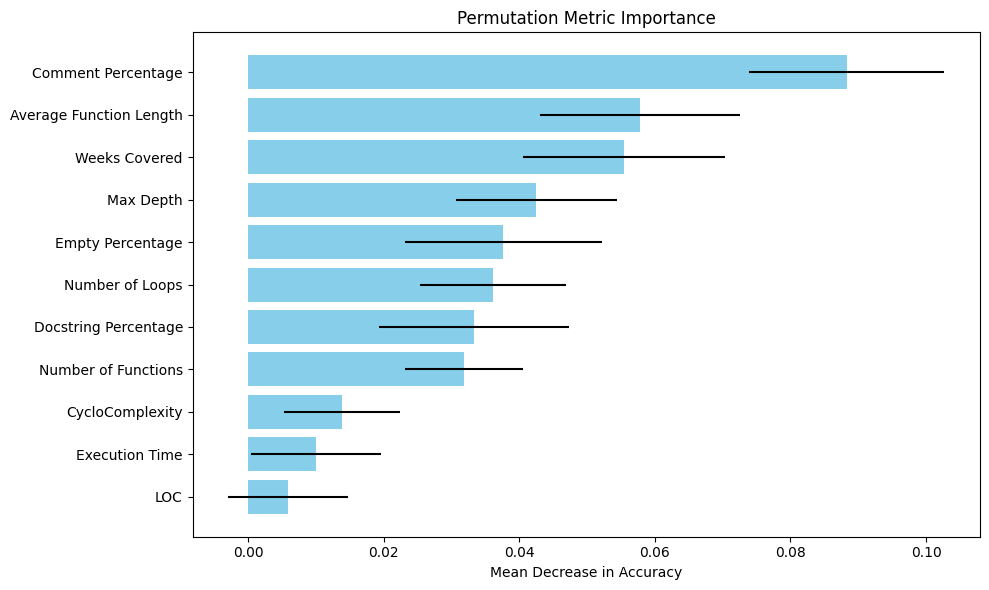

In [41]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_knn, X_test_scaled, y_test, 
    n_repeats=30, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance_mean'], 
         xerr=importance_df['importance_std'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Permutation Metric Importance')
plt.xlabel('Mean Decrease in Accuracy')
plt.tight_layout()
plt.show()